In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as mcolors

import condensed_blosum_metric
from condensed_blosum_metric import new_blosum62


In [80]:
og_aa_list = ['A','R','N','D','C','Q','E','G','H','I','L','K','M','F','P','S','T','W','Y','V']
wanted_aa_list = ["C", "S", "T", "P", "A", "G", "N", "D", "E", "Q", "H", "R", "K", "M", "I", "L", "V", "F", "Y", "W"]

In [81]:
data = np.array([[new_blosum62[og_aa_list[row]][og_aa_list[col]] for col in range(n)] for row in range(n)], dtype=float)
 

In [82]:
d = pd.DataFrame(data)

d


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,1.0000,0.2857,0.1429,0.1429,0.4286,0.2857,0.2857,0.4286,0.1429,0.2857,0.2857,0.2857,0.2857,0.1429,0.2857,0.5714,0.4286,0.0000,0.1429,0.4286
1,0.2500,1.0000,0.3750,0.1250,0.0000,0.5000,0.3750,0.1250,0.3750,0.0000,0.1250,0.6250,0.2500,0.0000,0.1250,0.2500,0.2500,0.0000,0.1250,0.0000
2,0.2000,0.4000,1.0000,0.5000,0.1000,0.4000,0.4000,0.4000,0.5000,0.1000,0.1000,0.4000,0.2000,0.1000,0.2000,0.5000,0.4000,0.0000,0.2000,0.1000
3,0.2000,0.2000,0.5000,1.0000,0.1000,0.4000,0.6000,0.3000,0.3000,0.1000,0.0000,0.3000,0.1000,0.1000,0.3000,0.4000,0.3000,0.0000,0.1000,0.1000
4,0.3077,0.0769,0.0769,0.0769,1.0000,0.0769,0.0000,0.0769,0.0769,0.2308,0.2308,0.0769,0.2308,0.1538,0.0769,0.2308,0.2308,0.1538,0.1538,0.2308
5,0.2500,0.5000,0.3750,0.3750,0.0000,1.0000,0.6250,0.1250,0.3750,0.0000,0.1250,0.5000,0.3750,0.0000,0.2500,0.3750,0.2500,0.1250,0.2500,0.1250
6,0.3333,0.4444,0.4444,0.6667,0.0000,0.6667,1.0000,0.2222,0.4444,0.1111,0.1111,0.5556,0.2222,0.1111,0.3333,0.4444,0.3333,0.1111,0.2222,0.2222
7,0.4000,0.2000,0.4000,0.3000,0.1000,0.2000,0.2000,1.0000,0.2000,0.0000,0.0000,0.2000,0.1000,0.1000,0.2000,0.4000,0.2000,0.2000,0.1000,0.1000
8,0.0909,0.2727,0.3636,0.1818,0.0000,0.2727,0.2727,0.0909,1.0000,0.0000,0.0000,0.1818,0.0909,0.1818,0.0909,0.1818,0.0909,0.0909,0.4545,0.0000
9,0.3750,0.1250,0.1250,0.1250,0.3750,0.1250,0.1250,0.0000,0.1250,1.0000,0.7500,0.1250,0.6250,0.5000,0.1250,0.2500,0.3750,0.1250,0.3750,0.8750


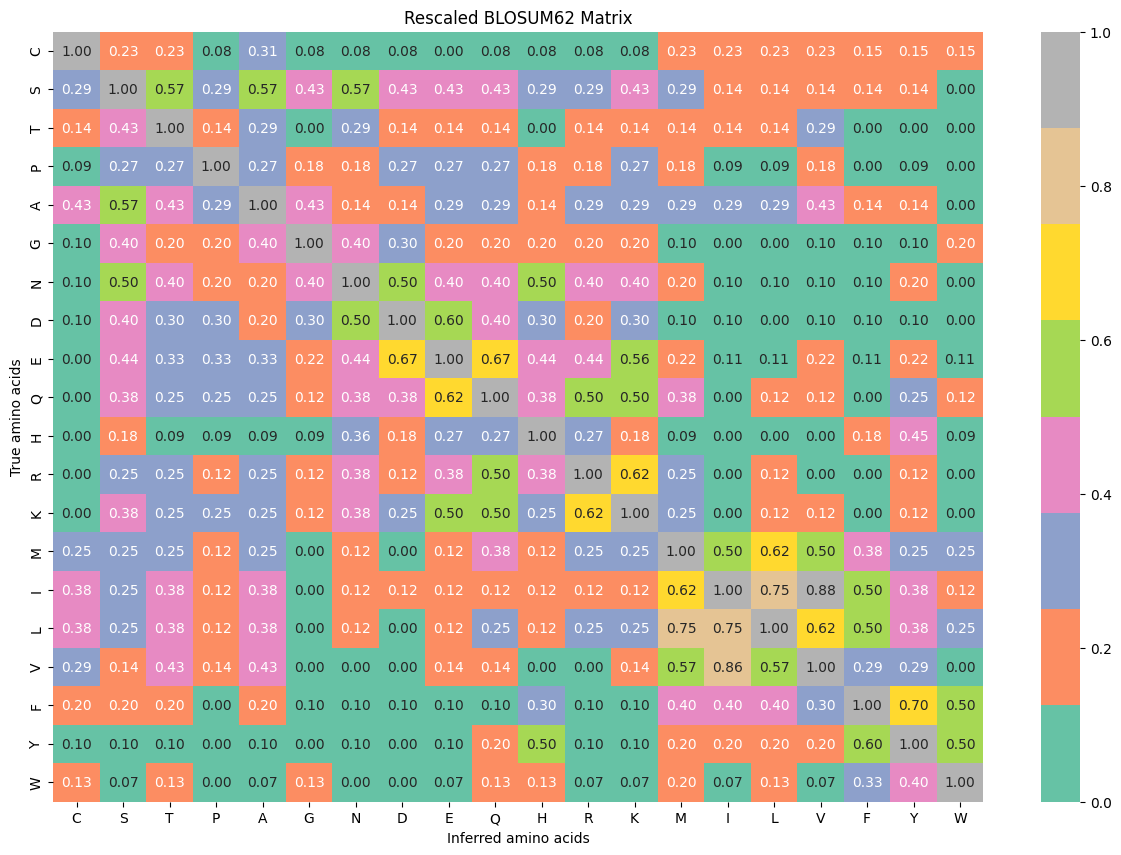

In [86]:
d = pd.DataFrame(data)
x = -1
for i in og_aa_list:
    x+=1
    d.rename(columns = {x:i}, inplace=True)
    d.rename(index = {x:i}, inplace = True)

d.index = pd.CategoricalIndex(d.index, categories= wanted_aa_list)
d.sort_index(level=0, inplace=True)
heatmap_table = d.reindex(wanted_aa_list, axis=1)
fig, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(heatmap_table, annot=True, vmin = 0, vmax= 1, fmt = ".2f", ax = ax, 
            cmap="Set2").set(xlabel = "Inferred amino acids", ylabel = "True amino acids")
plt.title("Rescaled BLOSUM62 Matrix")
plt.savefig(f"./results/heat-RescaledBLOSUM62.png", bbox_inches='tight')
plt.show() 